<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/TEG009b.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

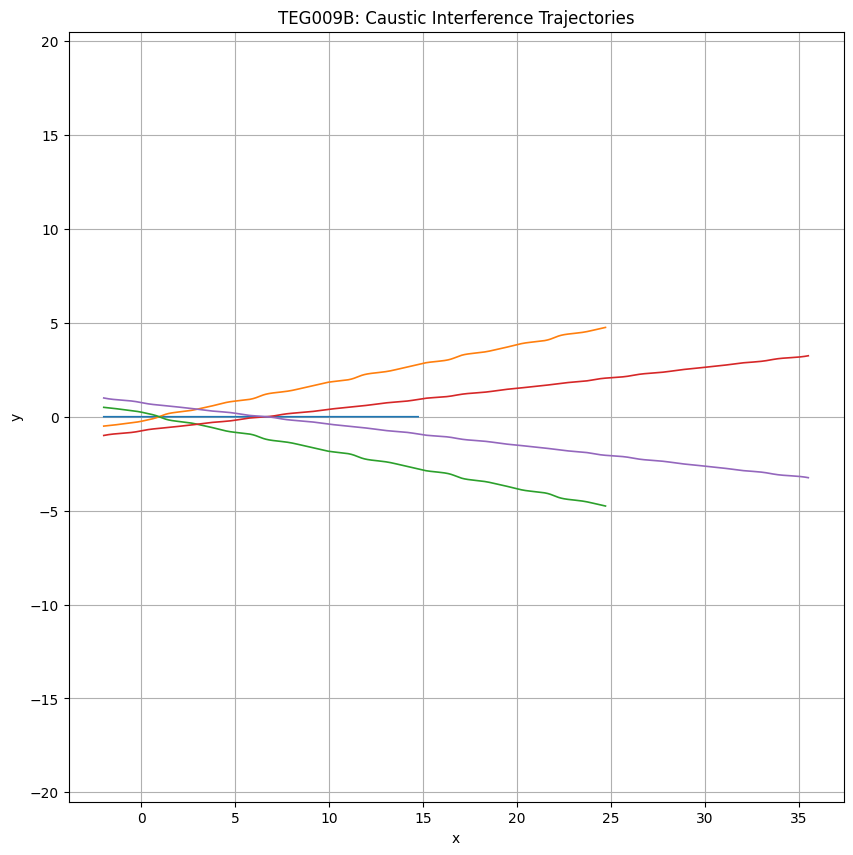

In [1]:
# 🧬 TEG009B: Caustic Interference
# Multi-attractor launch to test scattering and convergence in entropic folds
# Author: Chris & Copilot | Arc VIII: Tensorial Emergence

import numpy as np
import matplotlib.pyplot as plt

# 📐 Curvature Tensor (Folded Field)
def curvature_tensor(x, y, sigma=0.3, epsilon=0.6):
    exp_term = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    fold = np.sin(3 * x) * np.cos(3 * y)
    Cxx = (1 - x**2 / sigma**2) * exp_term * (1 + epsilon) + fold
    Cyy = (1 - y**2 / sigma**2) * exp_term * (1 - epsilon) - fold
    Cxy = (-x * y / sigma**2) * exp_term
    return np.array([[Cxx, Cxy], [Cxy, Cyy]])

# 🧲 Tensor Force
def tensor_force(x, y, vx, vy, sigma=0.3, epsilon=0.6):
    C = curvature_tensor(x, y, sigma, epsilon)
    v = np.array([vx, vy])
    f = -np.dot(C, v)
    return f[0], f[1]

# 🔁 Velocity Update
def update_velocity(vx, vy, fx, fy, dt):
    return vx + fx * dt, vy + fy * dt

# 🚀 Simulation Loop
def simulate_trajectory(x0, y0, vx0, vy0, steps=3000, dt=0.01, sigma=0.3, epsilon=0.6):
    x, y = x0, y0
    vx, vy = vx0, vy0
    trajectory = []

    for _ in range(steps):
        fx, fy = tensor_force(x, y, vx, vy, sigma, epsilon)
        vx, vy = update_velocity(vx, vy, fx, fy, dt)
        x += vx * dt
        y += vy * dt
        trajectory.append((x, y))

    return np.array(trajectory)

# 📊 Plot Multiple Trajectories
def plot_multiple_trajectories(trajectories):
    plt.figure(figsize=(10, 10))
    for traj in trajectories:
        x_vals, y_vals = traj[:,0], traj[:,1]
        plt.plot(x_vals, y_vals, linewidth=1.2)
    plt.title("TEG009B: Caustic Interference Trajectories")
    plt.xlabel("x")
    plt.ylabel("y")
    plt.grid(True)
    plt.axis('equal')
    plt.show()

# 🧪 Launch Multiple Attractors
launches = [
    (-2.0, 0.0, 1.0, 0.0),
    (-2.0, -0.5, 1.0, 0.1),
    (-2.0, 0.5, 1.0, -0.1),
    (-2.0, -1.0, 1.0, 0.2),
    (-2.0, 1.0, 1.0, -0.2),
]

trajectories = []
for x0, y0, vx0, vy0 in launches:
    traj = simulate_trajectory(x0, y0, vx0, vy0)
    trajectories.append(traj)

plot_multiple_trajectories(trajectories)
